## Этот код я стырила у себя же с прошлых гп

In [1]:
import pip
! pip install pandas
! pip install numpy
! pip install matplotlib
! pip install seaborn
! pip install scipy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('diabetic_data.csv')
df

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,MC,?,51,0,16,0,0,0,250.13,291,458,9,NaN,>8,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,MC,?,33,3,18,0,0,1,560,276,787,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,MC,?,53,0,9,1,0,0,38,590,296,13,NaN,NaN,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,MC,Surgery-General,45,2,21,0,0,1,996,285,998,9,NaN,NaN,No,No,No,No,No,No,Steady,No,No,Steady,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

encounter_id — уникальный ID каждой госпитализации
patient_nbr — уникальный ID пациента. Один пациент может встречаться несколько раз.

Демография пациента
race — раса пациента: African American, Asian, Caucasian, Hispanic, Other.
gender — пол: Female, Male, Unknown/Invalid.
age — возраст по бакетам: [0–10), [10–20), [20–30), [30–40), [40–50), [50–60), [60–70), [70–80), [80–90), [90–100).
weight — вес пациента.

Контекст госпитализации
admission_type_id — тип госпитализации в виде кода: экстренная, плановая, новорождённый и т.д.
discharge_disposition_id — куда выписан пациент (в виде кода): домой, в реабилитацию, в другое учреждение, умер.
admission_source_id — откуда поступил пациент (в виде кода): скорая, направление врача, перевод из другой больницы и т.д.
time_in_hospital — количество дней между поступлением и выпиской.
payer_code — код страховщика (Medicare, Medicaid, частная страховка и т.д.).
medical_specialty — специализация лечащего врача: кардиология, терапия, скорая помощь и т.д.

Медицинские показатели
num_lab_procedures — количество лабораторных анализов, сделанных во время госпитализации.
num_procedures — количество медицинских процедур (не считая лабораторных).
num_medications — количество уникальных препаратов, назначенных за время госпитализации.
number_diagnoses — общее количество диагнозов, внесённых в систему.
max_glu_serum — результат теста на глюкозу в сыворотке крови: >200, >300, Norm, None (тест не делали).
A1Cresult — результат теста на гликированный гемоглобин (HbA1c): >7, >8, Norm, None. Ключевой показатель управления диабетом.

Диагнозы (ICD-9 коды)
diag_1 — первичный (главный) диагноз. Числовой код ICD-9.
diag_2 — вторичный диагноз.
diag_3 — третичный диагноз.

История визитов за предыдущий год
number_outpatient — количество амбулаторных визитов пациента за год до текущей госпитализации.
number_emergency — количество обращений в скорую за предыдущий год.
number_inpatient — количество стационарных госпитализаций за предыдущий год.

23 лекарства от диабета
Для каждого лекарства значения одинаковые: No (не назначалось), Steady (доза не менялась), Up (доза повышена), Down (доза снижена).
metformin — самый распространённый препарат первой линии при диабете 2 типа. repaglinide, nateglinide, chlorpropamide, glimepiride, acetohexamide, glipizide, glyburide, tolbutamide — препараты класса сульфонилмочевина и меглитиниды, стимулируют выработку инсулина. pioglitazone, rosiglitazone — тиазолидиндионы, повышают чувствительность к инсулину. acarbose, miglitol — ингибиторы альфа-глюкозидазы, замедляют всасывание сахара. troglitazone, tolazamide, examide, citoglipton — редкие препараты. insulin — инсулин. glyburide-metformin, glipizide-metformin, glimepiride-pioglitazone, metformin-rosiglitazone, metformin-pioglitazone — комбинированные препараты.

Итоговые признаки
change — менялась ли схема приёма диабетических препаратов во время госпитализации: Ch (изменение было), No.
diabetesMed — назначался ли хоть один диабетический препарат: Yes / No.
readmitted — целевая переменная: NO (не госпитализирован повторно), <30 (повторная госпитализация в течение 30 дней), >30 (повторная госпитализация позже 30 дней).

Все коды расшифрованы в файле IDs_mapping.csv.

In [4]:
df = df.drop(columns=['encounter_id', 'weight'])

df['gender'] = df['gender'].replace({
    'Female': 0,
    'Male': 1,
    'Unknown/Invalid': np.nan})


df['age'] = df['age'].map({
    '[0-10)': 0,
    '[10-20)': 1,
    '[20-30)': 2,
    '[30-40)': 3,
    '[40-50)': 4,
    '[50-60)': 5,
    '[60-70)': 6,
    '[70-80)': 7,
    '[80-90)': 8,
    '[90-100)': 9})


for col in ['race', 'payer_code', 'medical_specialty']:
    df[col] = df[col].replace('?', 'Missing')

freq = df['medical_specialty'].value_counts(normalize=True)
rare = freq[freq < 0.01].index

df['medical_specialty'] = df['medical_specialty'].replace(rare, 'Other')


df['max_glu_serum'] = df['max_glu_serum'].fillna('None').map({
    'None': 0,
    'Norm': 1,
    '>200': 2,
    '>300': 3})

df['A1Cresult'] = df['A1Cresult'].fillna('None').map({
    'None': 0,
    'Norm': 1,
    '>7': 2,
    '>8': 3})


drug_cols = [
    'metformin','repaglinide','nateglinide','chlorpropamide',
    'glimepiride','acetohexamide','glipizide','glyburide',
    'tolbutamide','pioglitazone','rosiglitazone','acarbose',
    'miglitol','troglitazone','tolazamide','examide',
    'citoglipton','insulin','glyburide-metformin',
    'glipizide-metformin','glimepiride-pioglitazone',
    'metformin-rosiglitazone','metformin-pioglitazone']


for col in drug_cols:
    df[col] = df[col].map({
    'No': 0,
    'Steady': 1,
    'Down': 2,
    'Up': 3})


df['change'] = df['change'].map({'No': 0, 'Ch': 1})
df['diabetesMed'] = df['diabetesMed'].map({'No': 0, 'Yes': 1})


df['readmitted'] = df['readmitted'].map({
    'NO': 0,
    '>30': 1,
    '<30': 2
})


ohe_cols = ['race', 'payer_code', 'medical_specialty', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id']

df = pd.get_dummies(
    df,
    columns=ohe_cols,
    drop_first=True)

Делим диагнозы по категориям согласно классификации https://meps.ipums.org/meps/icd9_codes.shtml

In [5]:
def map_icd9(code):

    if pd.isna(code):
        return 'Missing'

    code = str(code).strip()

    if code.startswith('V'):
        return 'Supplementary_Factors'

    if code.startswith('E'):
        return 'External_Causes'

    try:
        num = float(code)
    except ValueError:
        return 'Unknown'

    if 1 <= num <= 139:
        return 'Infectious_Parasitic'

    elif 140 <= num <= 239:
        return 'Neoplasms'

    elif 240 <= num <= 279:
        return 'Endocrine_Metabolic_Immunity'

    elif 280 <= num <= 289:
        return 'Blood_Diseases'

    elif 290 <= num <= 319:
        return 'Mental_Disorders'

    elif 320 <= num <= 389:
        return 'Nervous_Sense_Organs'

    elif 390 <= num <= 459:
        return 'Circulatory'

    elif 460 <= num <= 519:
        return 'Respiratory'

    elif 520 <= num <= 579:
        return 'Digestive'

    elif 580 <= num <= 629:
        return 'Genitourinary'

    elif 630 <= num <= 679:
        return 'Pregnancy_Childbirth'

    elif 680 <= num <= 709:
        return 'Skin_Subcutaneous'

    elif 710 <= num <= 739:
        return 'Musculoskeletal'

    elif 740 <= num <= 759:
        return 'Congenital_Anomalies'

    elif 760 <= num <= 779:
        return 'Perinatal'

    elif 780 <= num <= 799:
        return 'Symptoms_IllDefined'

    elif 800 <= num <= 999:
        return 'Injury_Poisoning'

    else:
        return 'Unknown'


diag_cols = ['diag_1', 'diag_2', 'diag_3']

for col in diag_cols:
    df[col] = df[col].apply(map_icd9)

In [6]:
df = pd.get_dummies(
    df,
    columns=diag_cols,
    drop_first=True,
    dtype=int
)

In [7]:
df

,patient_nbr,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,race_Asian,race_Caucasian,race_Hispanic,race_Missing,race_Other,payer_code_CH,payer_code_CM,payer_code_CP,payer_code_DM,payer_code_FR,payer_code_HM,payer_code_MC,payer_code_MD,payer_code_MP,payer_code_Missing,payer_code_OG,payer_code_OT,payer_code_PO,payer_code_SI,payer_code_SP,payer_code_UN,payer_code_WC,medical_specialty_Emergency/Trauma,medical_specialty_Family/GeneralPractice,medical_specialty_InternalMedicine,medical_specialty_Missing,medical_specialty_Nephrology,medical_specialty_Orthopedics,medical_specialty_Orthopedics-Reconstructive,medical_specialty_Other,medical_specialty_Radiologist,medical_specialty_Surgery-General,admission_type_id_2,admission_type_id_3,admission_type_id_4,admission_type_id_5,admission_type_id_6,admission_type_id_7,admission_type_id_8,discharge_disposition_id_2,discharge_disposition_id_3,discharge_disposition_id_4,discharge_disposition_id_5,discharge_disposition_id_6,discharge_disposition_id_7,discharge_disposition_id_8,discharge_disposition_id_9,discharge_disposition_id_10,discharge_disposition_id_11,discharge_disposition_id_12,discharge_disposition_id_13,discharge_disposition_id_14,discharge_disposition_id_15,discharge_disposition_id_16,discharge_disposition_id_17,discharge_disposition_id_18,discharge_disposition_id_19,discharge_disposition_id_20,discharge_disposition_id_22,discharge_disposition_id_23,discharge_disposition_id_24,discharge_disposition_id_25,discharge_disposition_id_27,discharge_disposition_id_28,admission_source_id_2,admission_source_id_3,admission_source_id_4,admission_source_id_5,admission_source_id_6,admission_source_id_7,admission_source_id_8,admission_source_id_9,admission_source_id_10,admission_source_id_11,admission_source_id_13,admission_source_id_14,admission_source_id_17,admission_source_id_20,admission_source_id_22,admission_source_id_25,diag_1_Circulatory,diag_1_Congenital_Anomalies,diag_1_Digestive,diag_1_Endocrine_Metabolic_Immunity,diag_1_External_Causes,diag_1_Genitourinary,diag_1_Infectious_Parasitic,diag_1_Injury_Poisoning,diag_1_Mental_Disorders,diag_1_Musculoskeletal,diag_1_Neoplasms,diag_1_Nervous_Sense_Organs,diag_1_Pregnancy_Childbirth,diag_1_Respiratory,diag_1_Skin_Subcutaneous,diag_1_Supplementary_Factors,diag_1_Symptoms_IllDefined,diag_1_Unknown,diag_2_Circulatory,diag_2_Congenital_Anomalies,diag_2_Digestive,diag_2_Endocrine_Metabolic_Immunity,diag_2_External_Causes,diag_2_Genitourinary,diag_2_Infectious_Parasitic,diag_2_Injury_Poisoning,diag_2_Mental_Disorders,diag_2_Musculoskeletal,diag_2_Neoplasms,diag_2_Nervous_Sense_Organs,diag_2_Pregnancy_Childbirth,diag_2_Respiratory,diag_2_Skin_Subcutaneous,diag_2_Supplementary_Factors,diag_2_Symptoms_IllDefined,diag_2_Unknown,diag_3_Circulatory,diag_3_Congenital_Anomalies,diag_3_Digestive,diag_3_Endocrine_Metabolic_Immunity,diag_3_External_Causes,diag_3_Genitourinary,diag_3_Infectious_Parasitic,diag_3_Injury_Poisoning,diag_3_Mental_Disorders,diag_3_Musculoskeletal,diag_3_Neoplasms,diag_3_Nervous_Sense_Organs,diag_3_Pregnancy_Childbirth,diag_3_Respiratory,diag_3_Skin_Subcutaneous,diag_3_Supplementary_Factors,diag_3_Symptoms_IllDefined,diag_3_Unknown
0,8222157,0,0,1,41,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,Fa

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Columns: 173 entries, patient_nbr to diag_3_Unknown
dtypes: bool(80), int64(92), object(1)
memory usage: 80.0+ MB


In [9]:
df.to_csv('diabetic_encoded.csv', index=False)

In [10]:
df.describe()

,patient_nbr,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,diag_1_Circulatory,diag_1_Congenital_Anomalies,diag_1_Digestive,diag_1_Endocrine_Metabolic_Immunity,diag_1_External_Causes,diag_1_Genitourinary,diag_1_Infectious_Parasitic,diag_1_Injury_Poisoning,diag_1_Mental_Disorders,diag_1_Musculoskeletal,diag_1_Neoplasms,diag_1_Nervous_Sense_Organs,diag_1_Pregnancy_Childbirth,diag_1_Respiratory,diag_1_Skin_Subcutaneous,diag_1_Supplementary_Factors,diag_1_Symptoms_IllDefined,diag_1_Unknown,diag_2_Circulatory,diag_2_Congenital_Anomalies,diag_2_Digestive,diag_2_Endocrine_Metabolic_Immunity,diag_2_External_Causes,diag_2_Genitourinary,diag_2_Infectious_Parasitic,diag_2_Injury_Poisoning,diag_2_Mental_Disorders,diag_2_Musculoskeletal,diag_2_Neoplasms,diag_2_Nervous_Sense_Organs,diag_2_Pregnancy_Childbirth,diag_2_Respiratory,diag_2_Skin_Subcutaneous,diag_2_Supplementary_Factors,diag_2_Symptoms_IllDefined,diag_2_Unknown,diag_3_Circulatory,diag_3_Congenital_Anomalies,diag_3_Digestive,diag_3_Endocrine_Metabolic_Immunity,diag_3_External_Causes,diag_3_Genitourinary,diag_3_Infectious_Parasitic,diag_3_Injury_Poisoning,diag_3_Mental_Disorders,diag_3_Musculoskeletal,diag_3_Neoplasms,diag_3_Nervous_Sense_Organs,diag_3_Pregnancy_Childbirth,diag_3_Respiratory,diag_3_Skin_Subcutaneous,diag_3_Supplementary_Factors,diag_3_Symptoms_IllDefined,diag_3_Unknown
count,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.0,101766.0,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,5.433040e+07,6.096702,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607,0.091966,0.366154,0.223031,0.017727,0.007488,0.000973,0.059342,0.000010,0.145294,0.126152,0.000226,0.077767,0.066899,0.003253,0.000462,0.000029,0.000403,0.0,0.0,0.876845,0.007154,0.000128,0.000010,0.000020,0.000010,0.461952,0.770031,0.572480,0.298096,0.000501,0.090482,0.112601,0.000010,0.049899,0.027200,0.068530,0.022227,0.048710,0.033734,0.011900,0.006751,0.102264,0.024861,0.016155,0.075035,0.000206,0.308207,0.001061,0.038932,0.206523,0.007183,0.078484,0.018975,0.023859,0.026109,0.017334,0.025028,0.012637,0.004078,0.100731,0.035336,0.017737,0.045516,0.003518,0.293988,0.000943,0.035100,0.258515,0.012224,0.062172,0.018287,0.019122,0.030816,0.018818,0.018238,0.017354,0.003036,0.066564,0.024448,0.037478,0.044445,0.013983
std,3.869636e+07,1.594084,2.985108,19.674362,1.705807,8.127566,1.267265,

In [11]:
numeric_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses', 'number_outpatient', 'number_emergency', 'number_inpatient']

Легендарное трио с пуссиплотом:

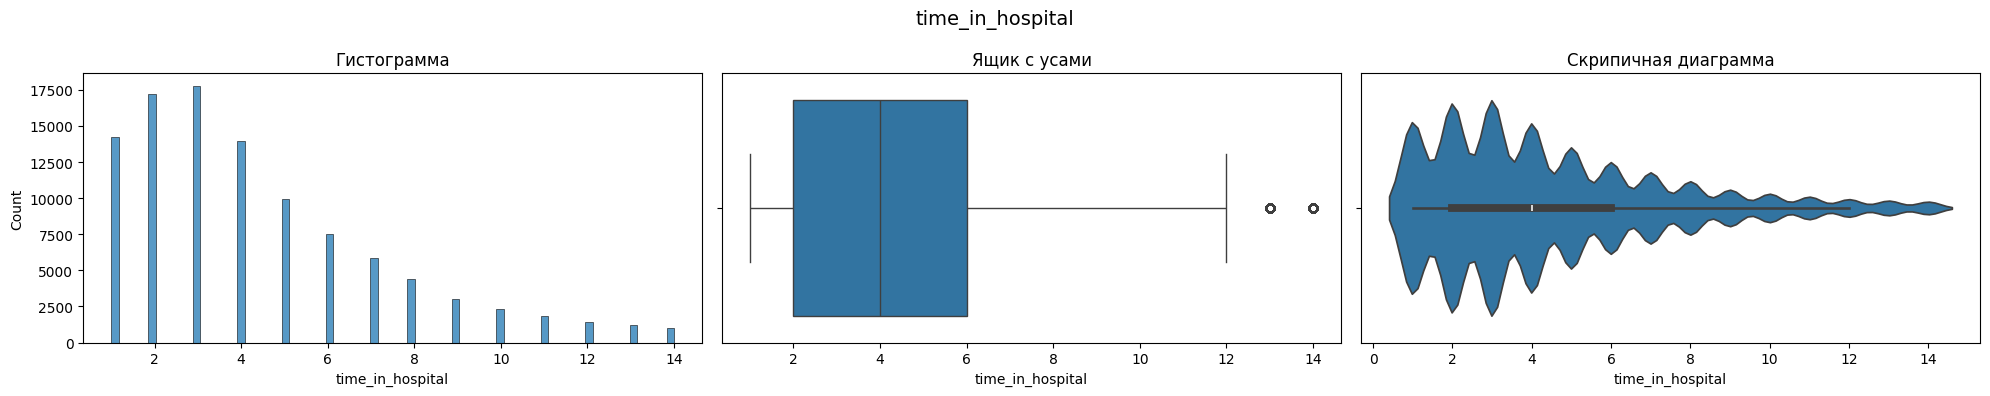

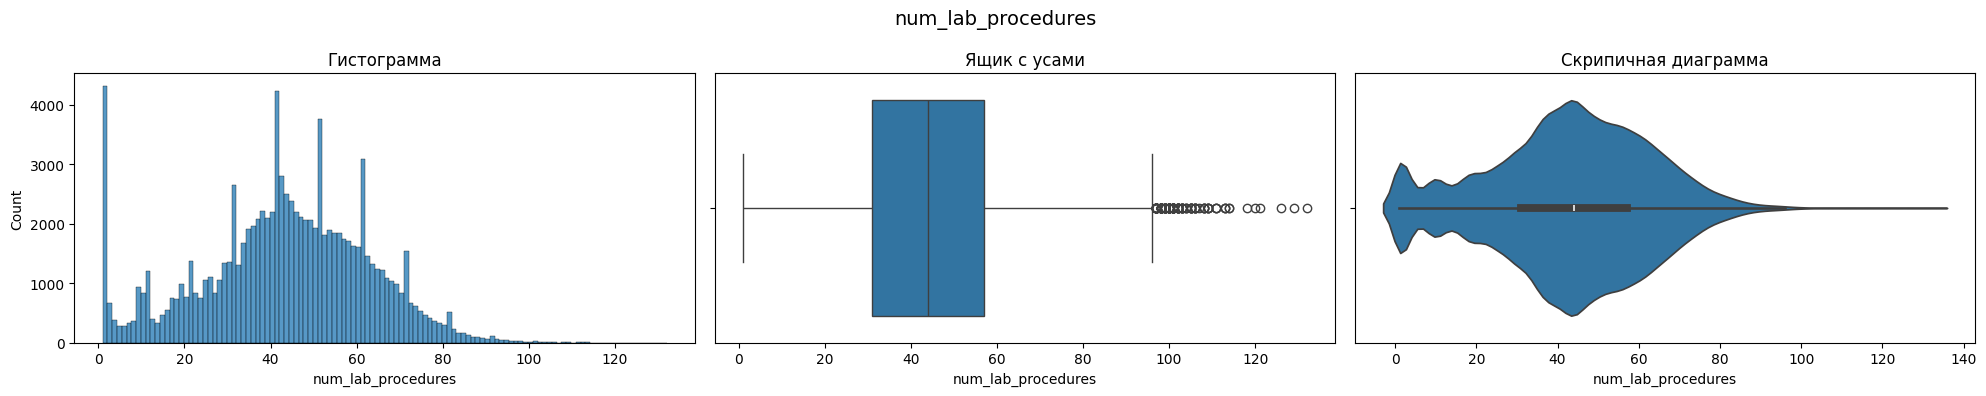

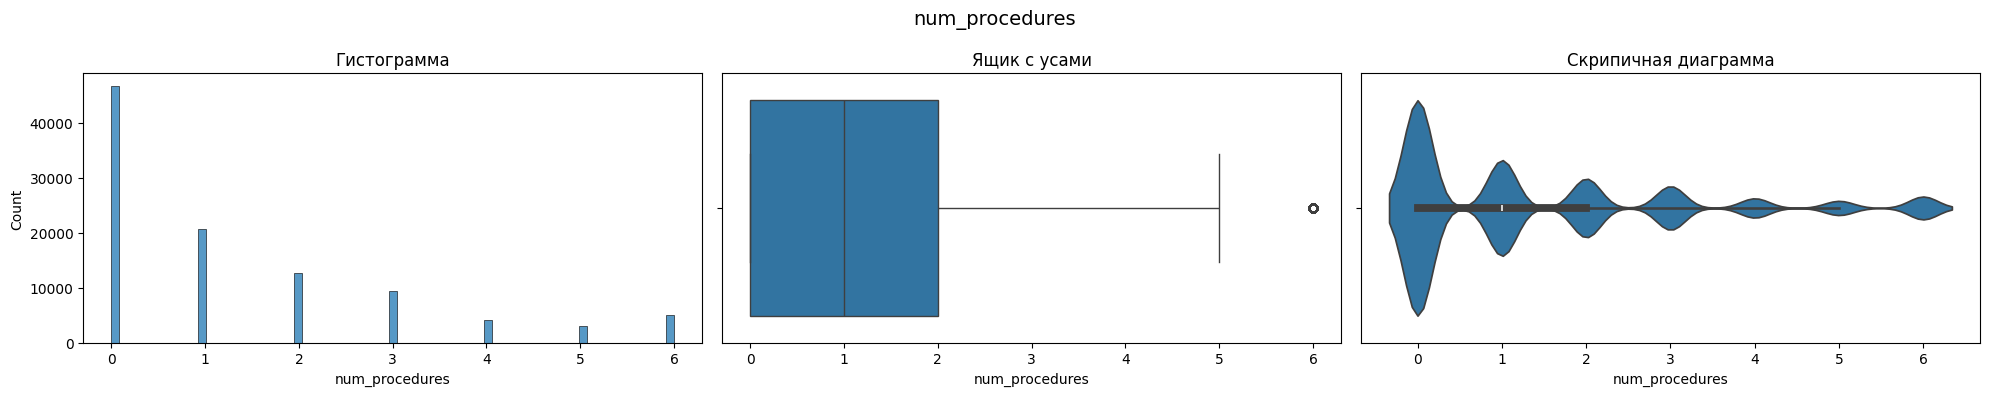

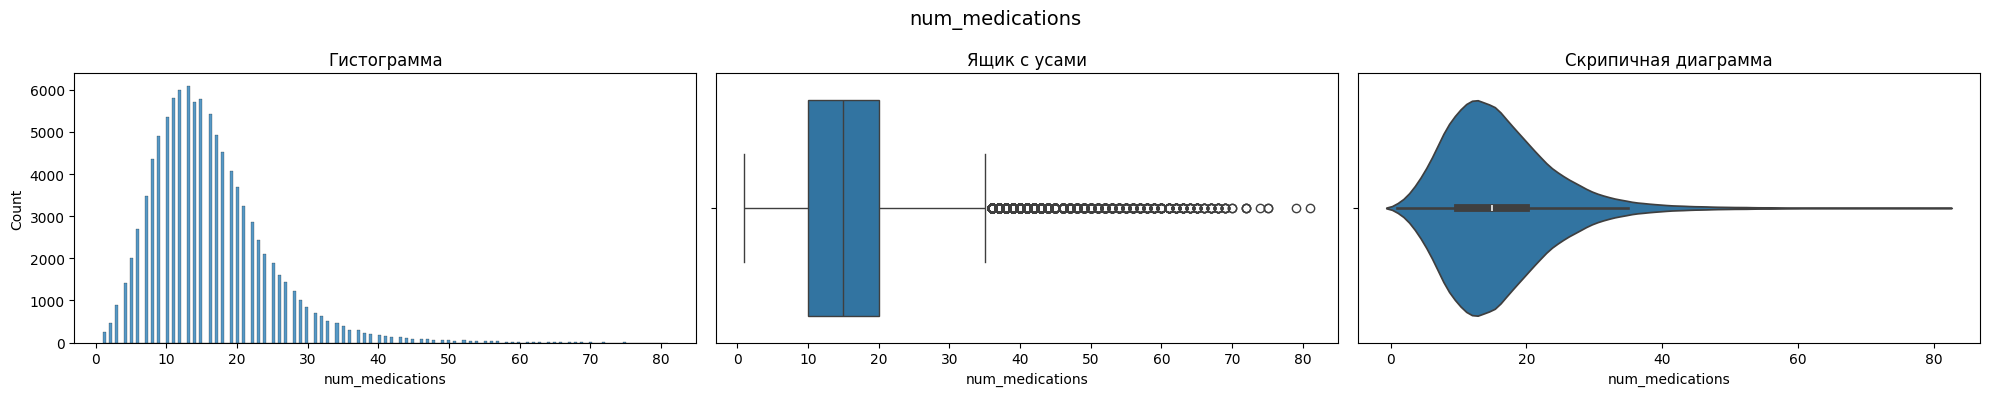

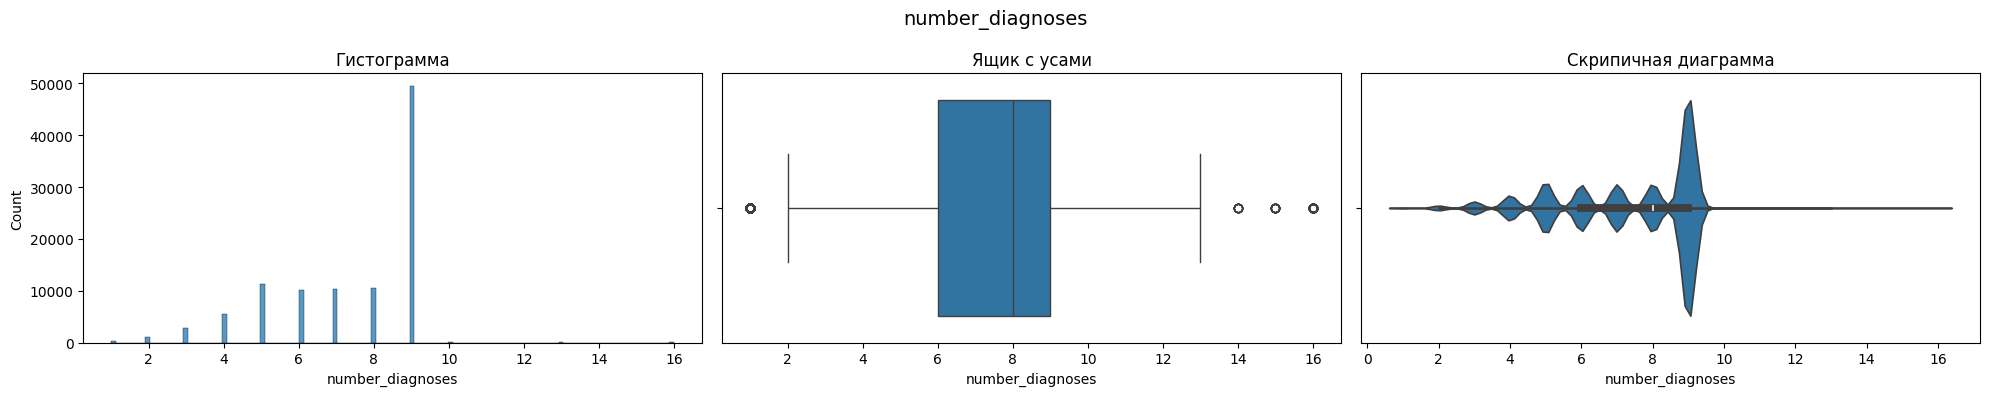

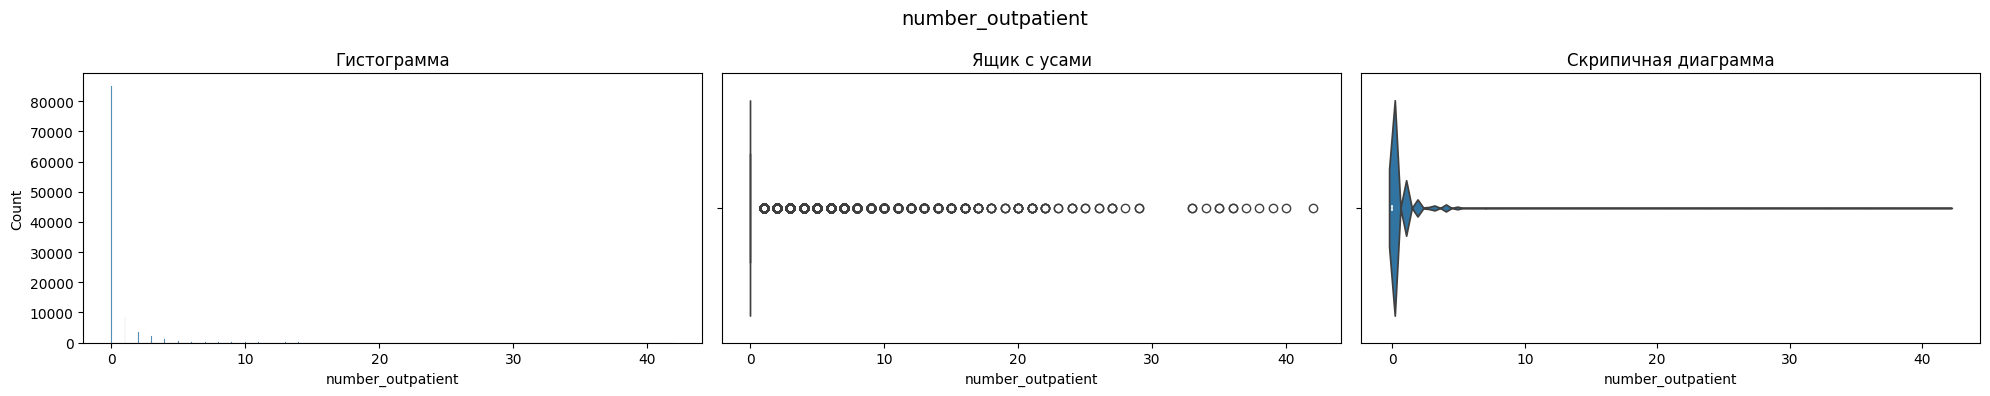

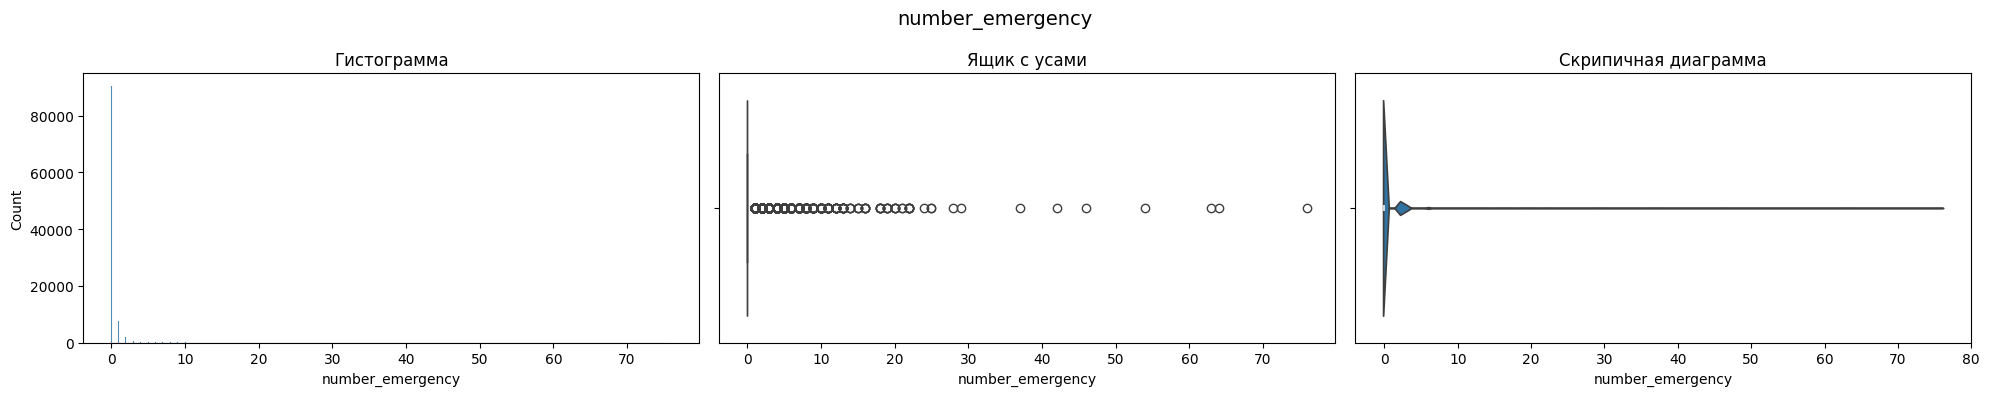

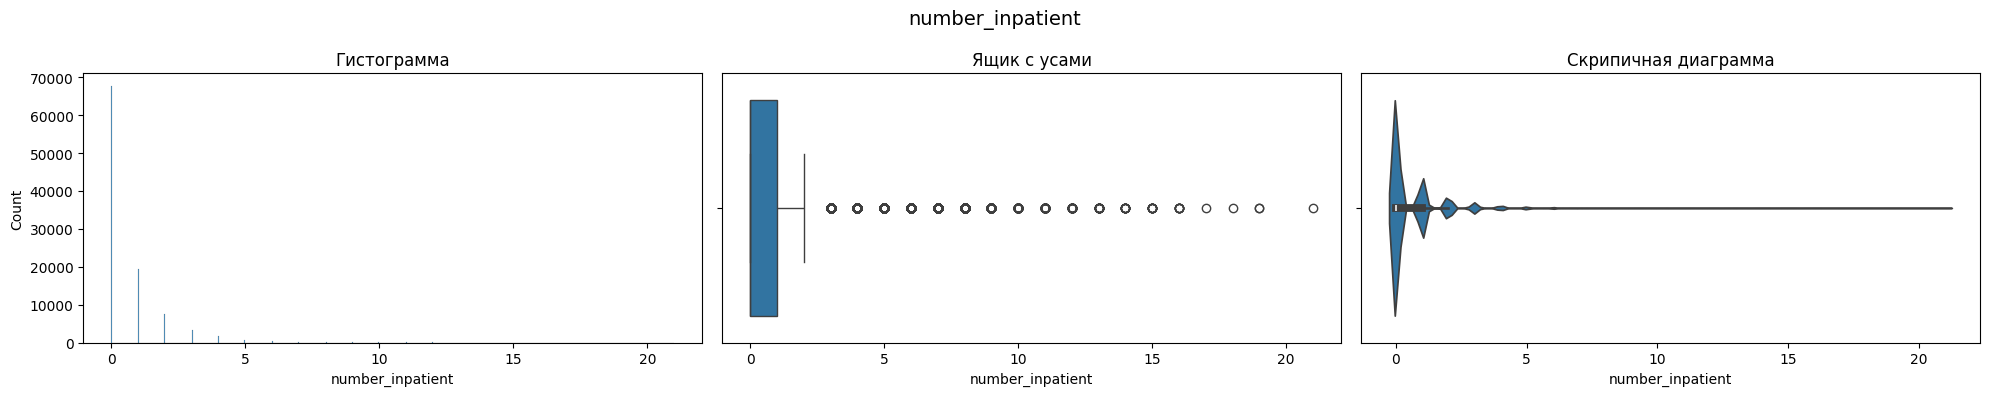

In [12]:
for col in numeric_cols:
    fig, axes = plt.subplots(1, 3, figsize=(20, 4))
    fig.suptitle(f'{col}', fontsize=14)
    sns.histplot(df[col], ax=axes[0])
    axes[0].set_title('Гистограмма')
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title('Ящик с усами')
    sns.violinplot(x=df[col], ax=axes[2])
    axes[2].set_title('Скрипичная диаграмма')
    plt.tight_layout()
    plt.show()

Хитмап:

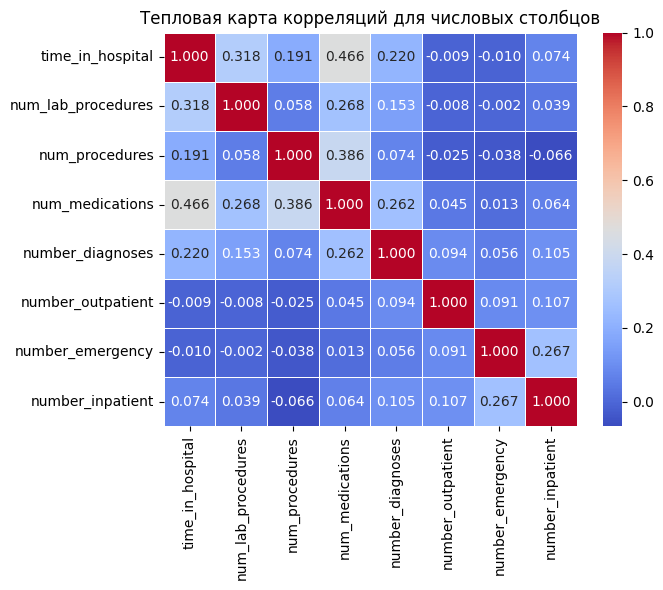

In [13]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', linewidths=0.5)
plt.title('Тепловая карта корреляций для числовых столбцов')
plt.tight_layout()
plt.show()

Пейрплоты

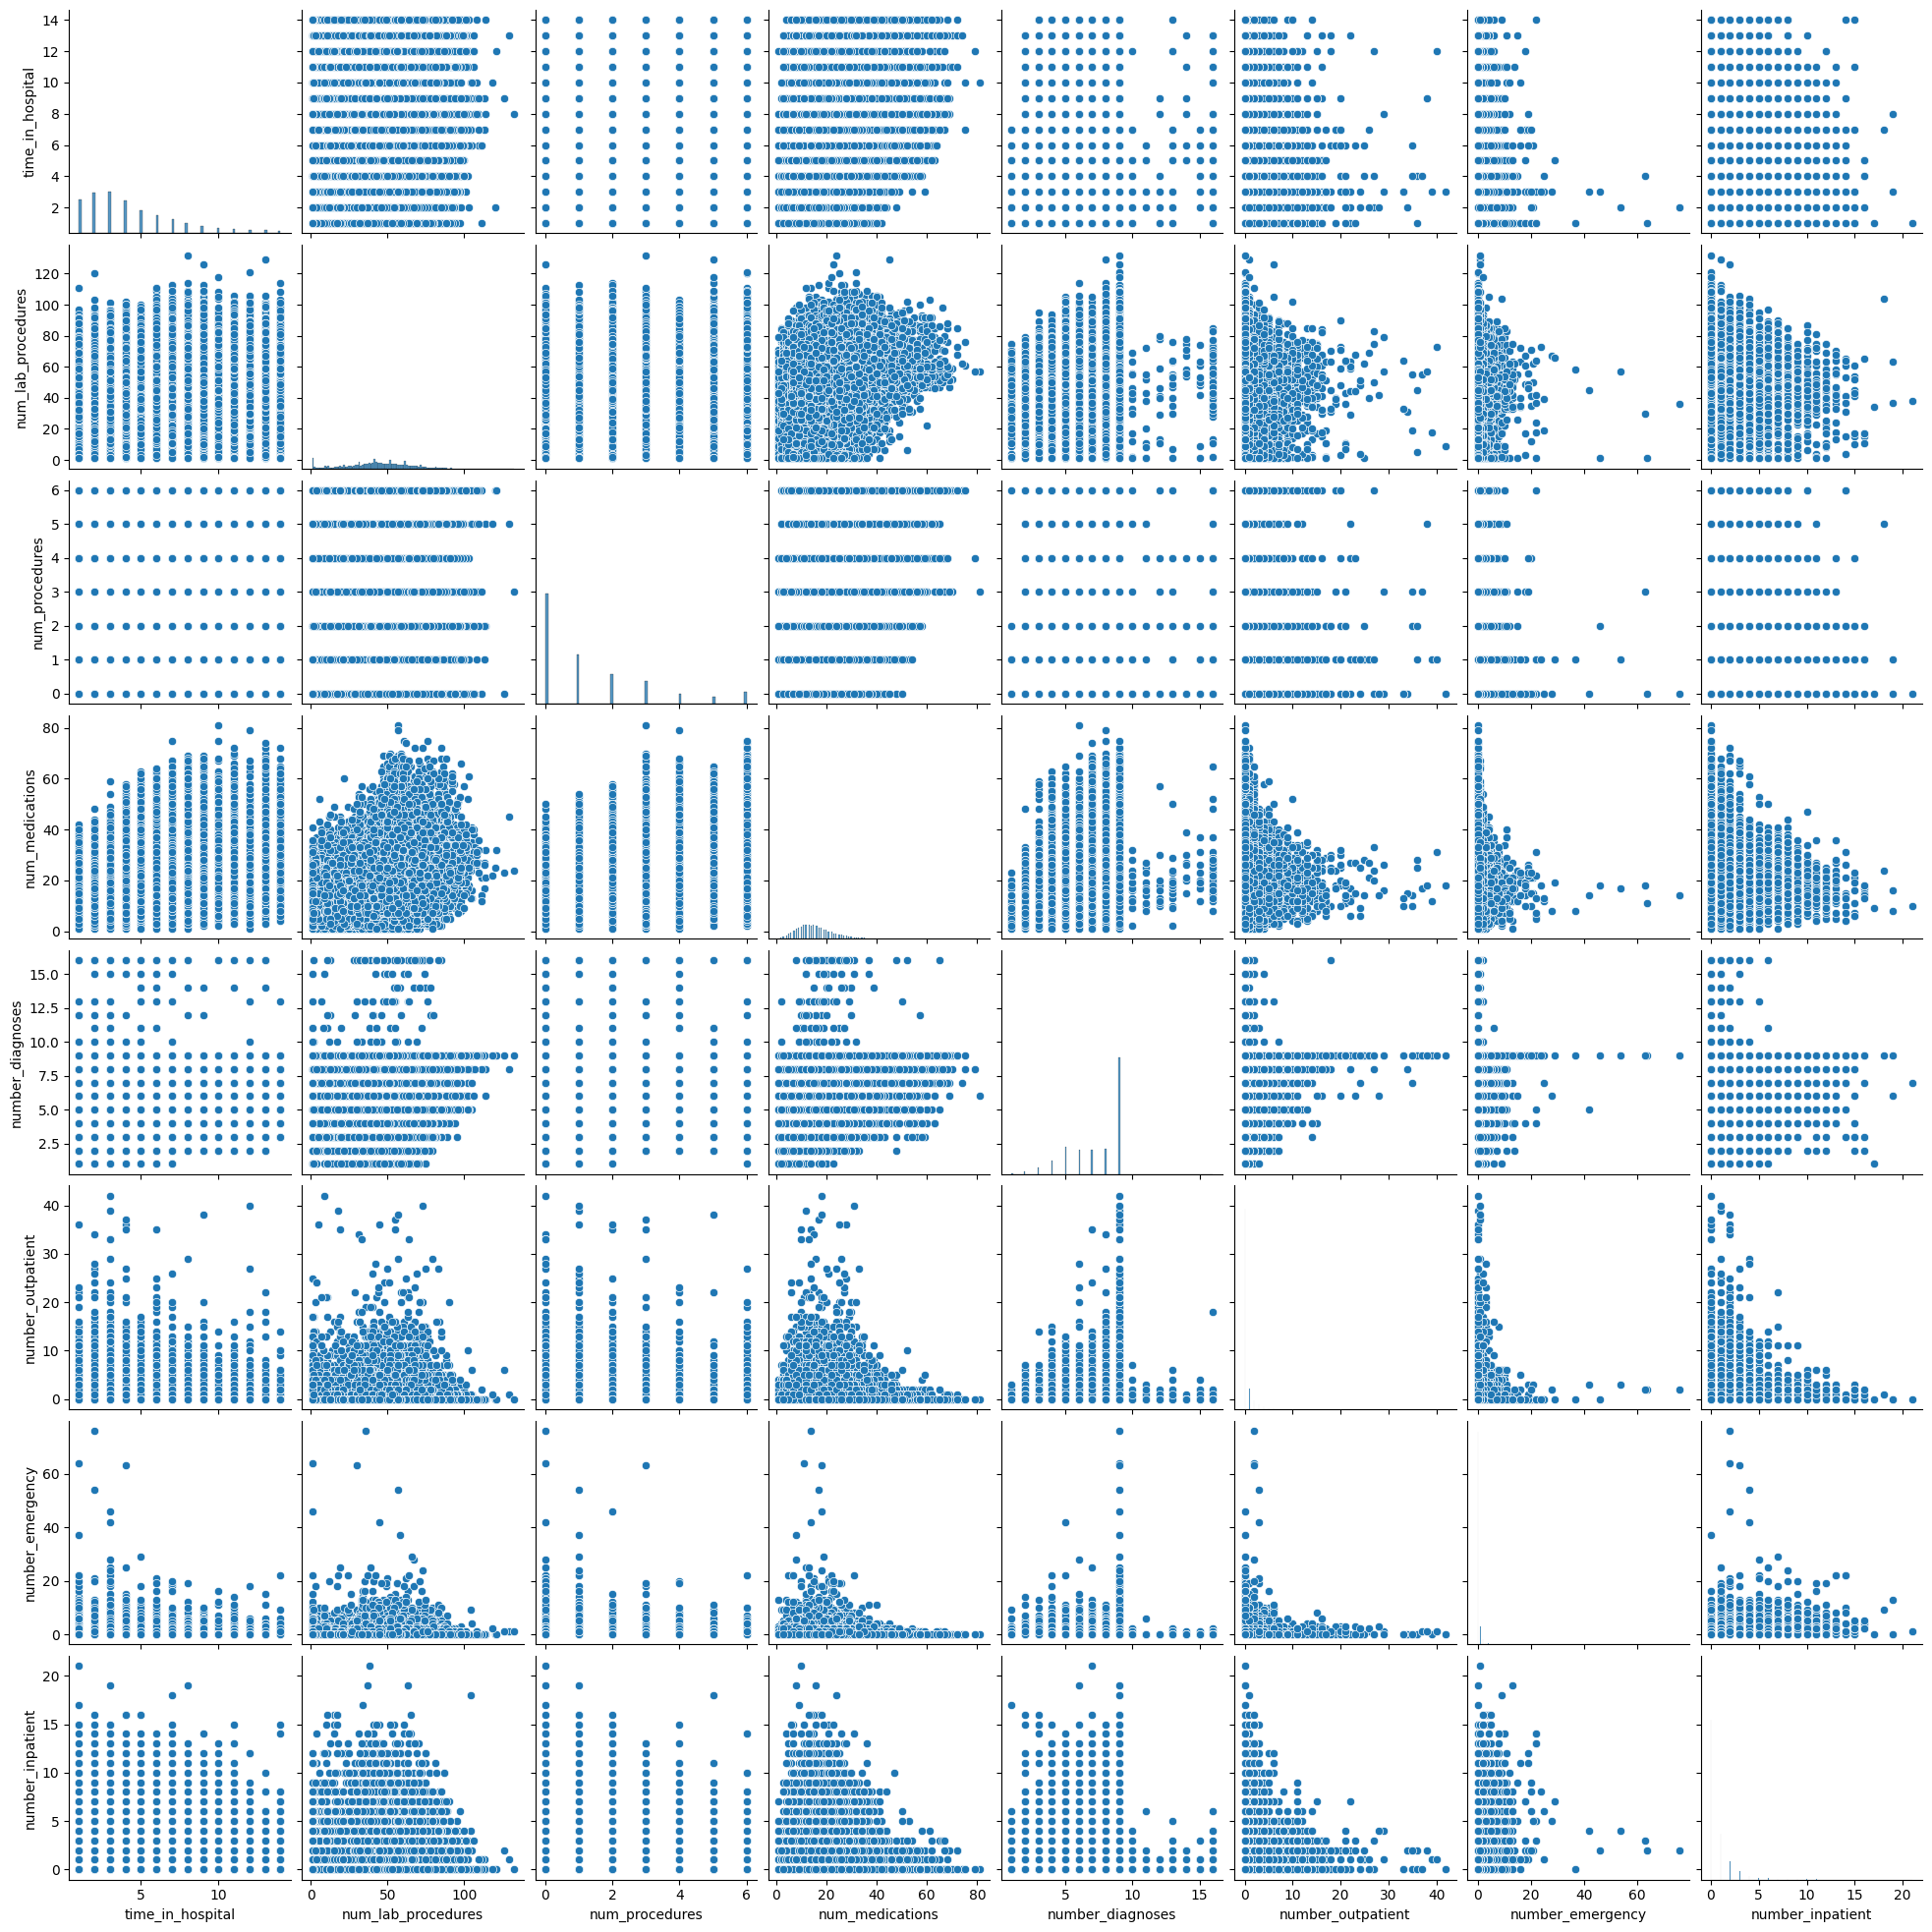

In [14]:
sns.pairplot(df[numeric_cols])
plt.show()

In [19]:
numeric_cols_1 = ['age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses', 'number_outpatient', 'number_emergency', 'number_inpatient', 'insulin', 'readmitted']

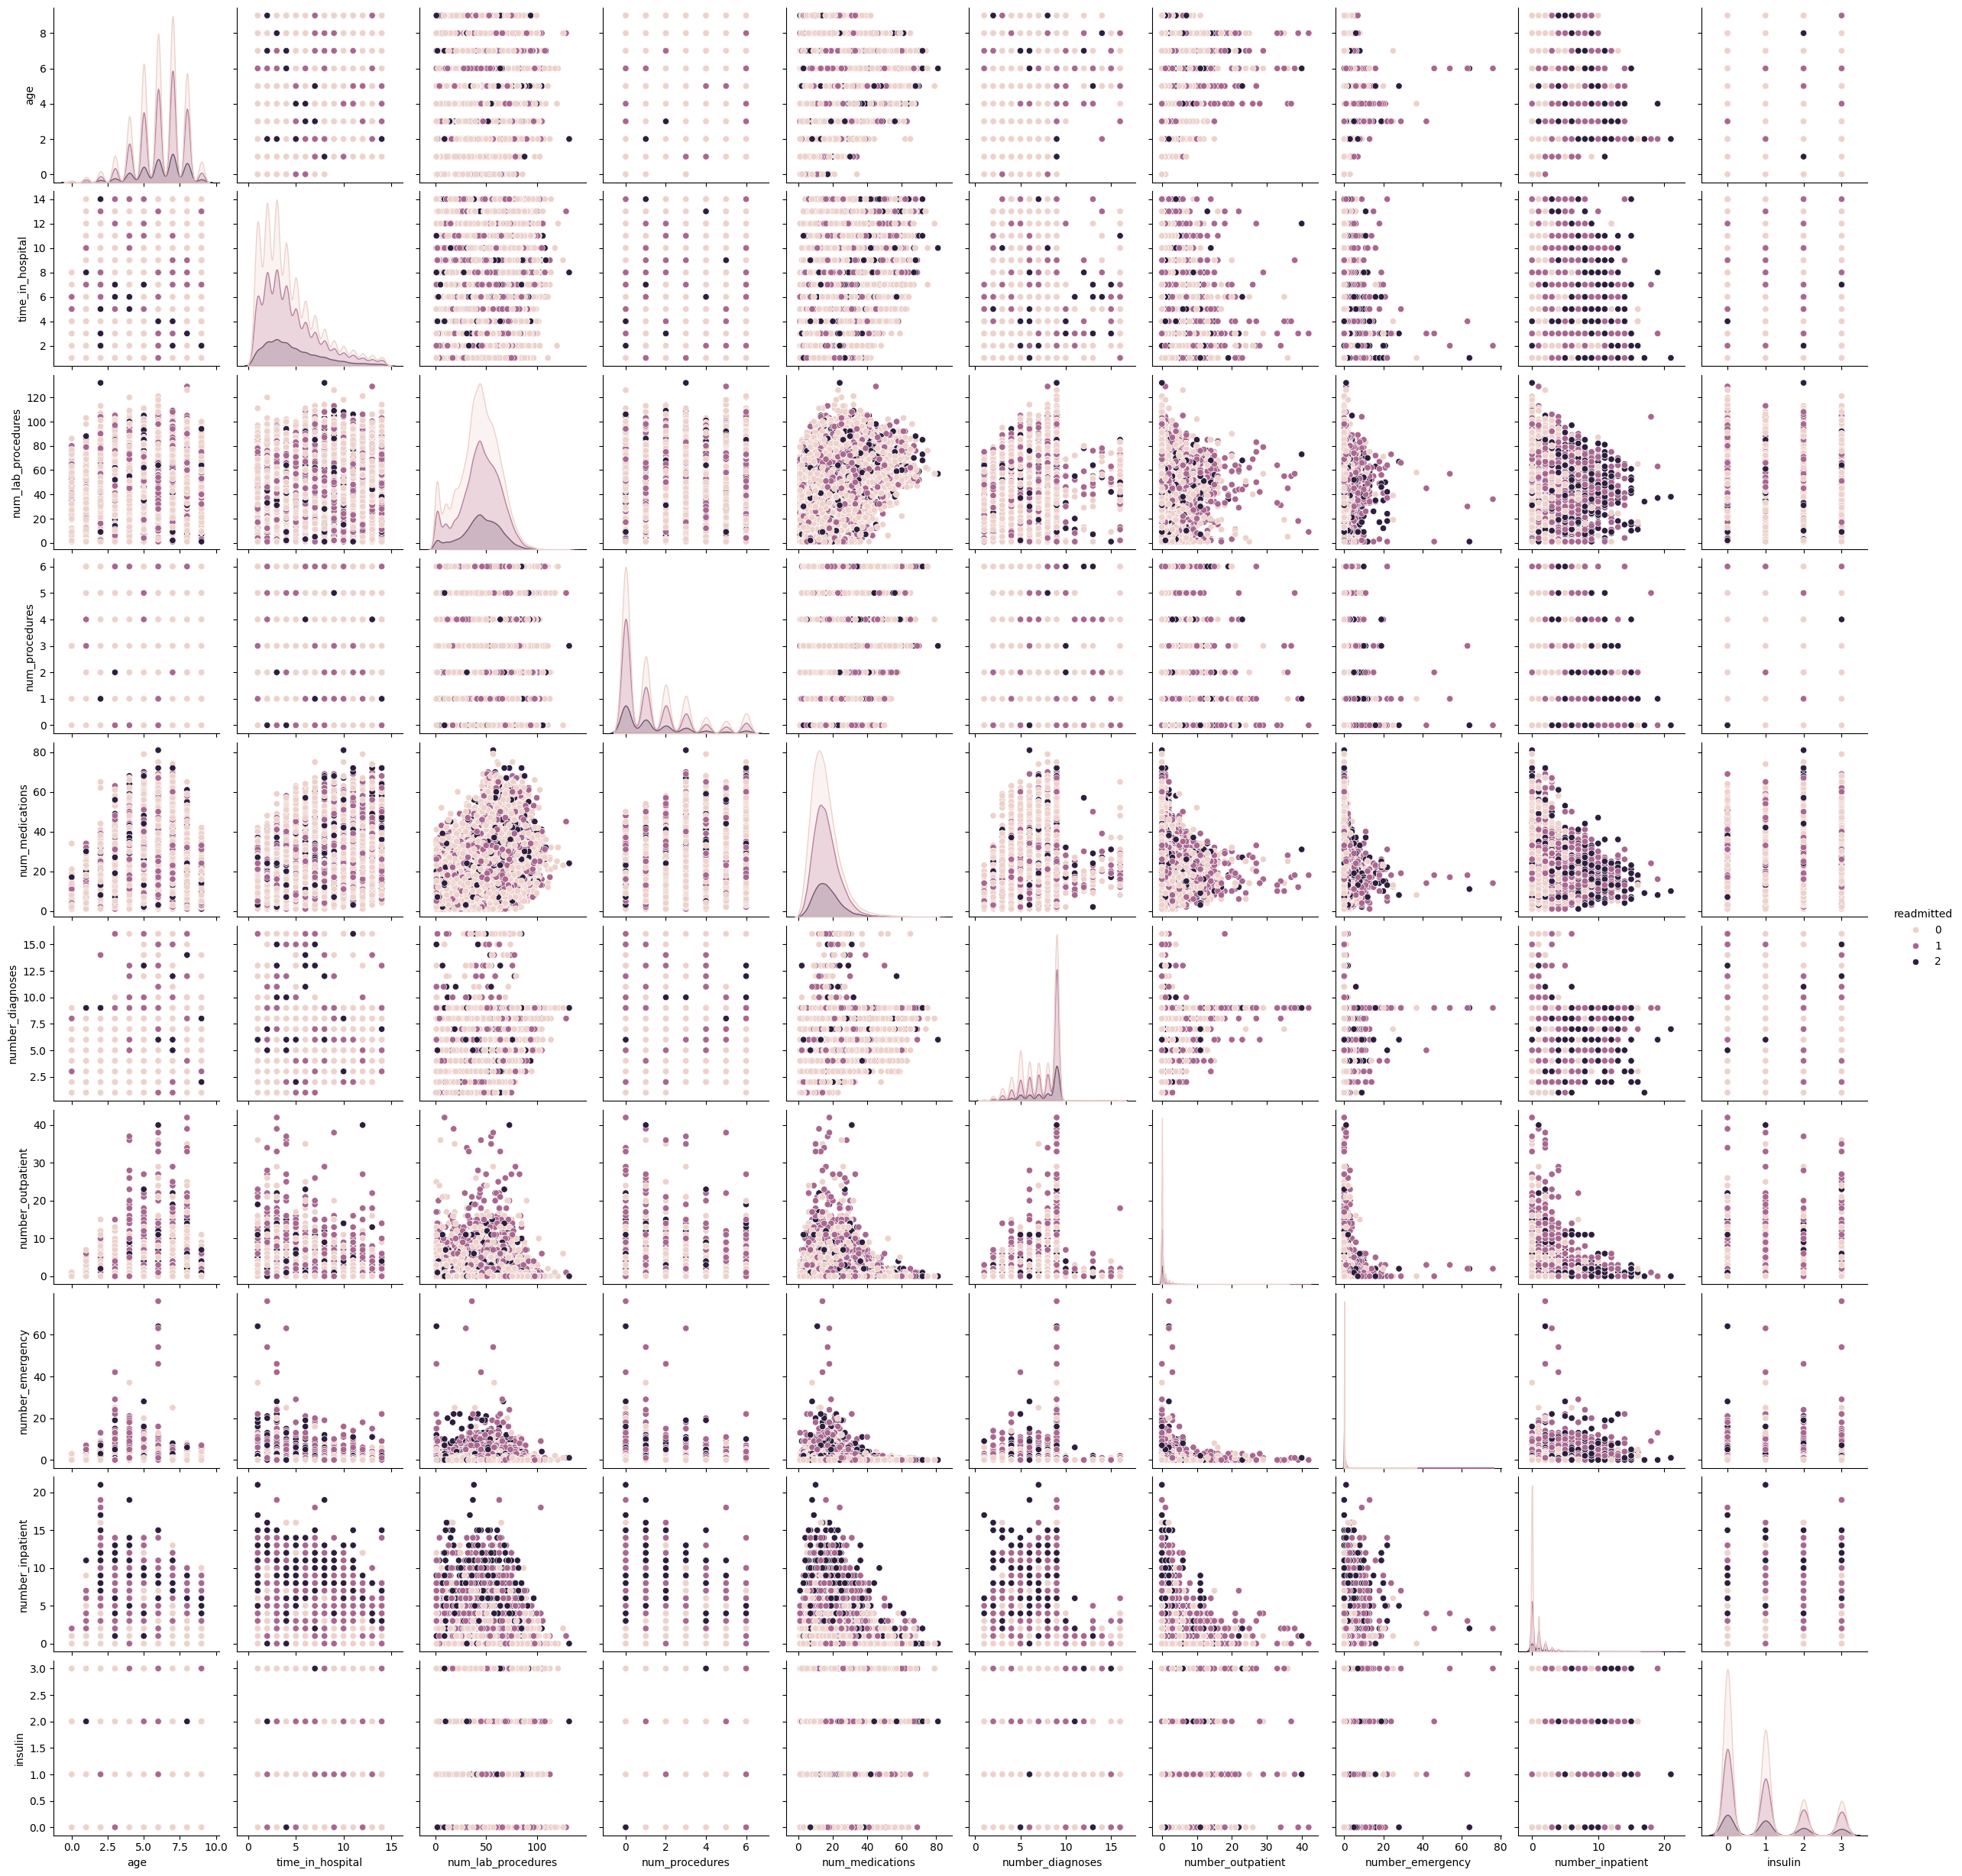

In [20]:
sns.pairplot(df[numeric_cols_1], hue='readmitted')
plt.show()